# Chapter 16: Integration on Manifolds

**Source Span.** *Introduction to Smooth Manifolds*, Chapter 16, printed pages 400-439. I inspected roughly PDF pages 418-457 with `pdftotext -layout`, including volume-measurement motivation, Euclidean integration of forms, coordinate invariance, partition-of-unity definitions on oriented manifolds, Stokes theorem, manifolds with corners, Riemannian integration, divergence/Stokes applications, and densities for nonorientable manifolds.

**Chapter goal.** Show why forms, not plain functions, integrate intrinsically on oriented manifolds: alternating tensors measure signed volume, pullbacks encode change of variables, partitions of unity assemble local chart integrals, Stokes turns `d` into a boundary operator, Riemannian metrics provide volume densities, and densities survive when orientation does not.

The source is used only for structure, terminology, theorem orientation, and concept coverage. The prose, code, visuals, and checks below are original.


## Translation Guide

| Chapter idea | Computational representation | What to inspect |
| --- | --- | --- |
| Signed volume meter | determinant of tangent vectors | orientation changes sign, dependence gives zero volume |
| Integral of an `n`-form | coefficient integral after erasing wedges | orientation-preserving maps preserve the value |
| Change of variables | pullback coefficient times Jacobian determinant | the determinant enters because the form is alternating |
| Partition of unity | weighted local integrals | the weights sum to one on the support |
| Stokes theorem | integral of `d omega` equals boundary integral of `omega` | boundary orientation and signs are essential |
| Corners | boundary pieces meeting in lower-dimensional faces | codimension-two corners cancel in boundary-of-boundary checks |
| Riemannian volume | `sqrt(det g)` density/form | metric supplies positive volume measure |
| Density | absolute-value top form | orientation flips do not change integrability |


## Planner Pass: Visual Storyboard and Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Integration dependency map | directed graph from signed volume to densities | NetworkX + Matplotlib | `figures/integration-concept-dependency.png` | graph reaches Stokes and densities |
| Signed volume meter | determinant/parallelogram visual | NumPy + Matplotlib | `figures/signed-volume-meter.png` | determinant changes sign under swap |
| Change of variables | pulled-back 2-form on a sheared square | SymPy + Matplotlib | `figures/change-of-variables-for-forms.png` | direct substituted integral matches pullback integral |
| Partition of unity assembly | bump weights and local integral pieces | NumPy + Matplotlib, CSV | `figures/partition-of-unity-integration.png` | weights sum to one and piece integrals add |
| Stokes/Green lab | rectangle boundary orientation and area form | SymPy + Matplotlib | `figures/stokes-green-rectangle.png` | boundary integral equals area integral |
| Corners and divergence | square boundary pieces and flux | NumPy + Matplotlib | `figures/corners-and-divergence-theorem.png` | divergence integral equals flux sum |
| Riemannian densities | metric volume heatmap and orientation flip table | SymPy + Matplotlib | `figures/riemannian-volume-density.png` | density positive under orientation flip |

Matplotlib handles durable teaching diagrams, SymPy handles exact integrals, NumPy handles numerical density checks, and CSV/JSON artifacts record the invariants.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-16-integration-on-manifolds"
SOURCE_SPAN = {
    "printed_pages": "400-439",
    "pdf_pages_inspected": "418-457",
    "pdftotext_command": "pdftotext -f 418 -l 457 -layout 'Introduction to Smooth Manifolds.pdf' -",
}
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
HTML = ARTIFACT_ROOT / "html"

artifacts: list[Path] = []
check_paths: list[Path] = []
computed_checks: dict[str, bool] = {}
coverage_topics = {
    "volume measurement": True,
    "Euclidean integration of forms": True,
    "diffeomorphism invariance": True,
    "partitions of unity": True,
    "Stokes theorem": True,
    "manifolds with corners": True,
    "Riemannian integration": True,
    "divergence theorem": True,
    "densities": True,
}


def artifact_record(path: Path) -> dict[str, object]:
    return {"path": Path(path).relative_to(BOOK_ROOT).as_posix(), "bytes": Path(path).stat().st_size}


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-16-integration-on-manifolds


## 1. Dependency Map: From Volume Meters to Densities

The chapter's architecture is local-to-global. First we learn what can be integrated in a coordinate-invariant way, then assemble chart integrals, then prove Stokes, then add Riemannian and density tools.


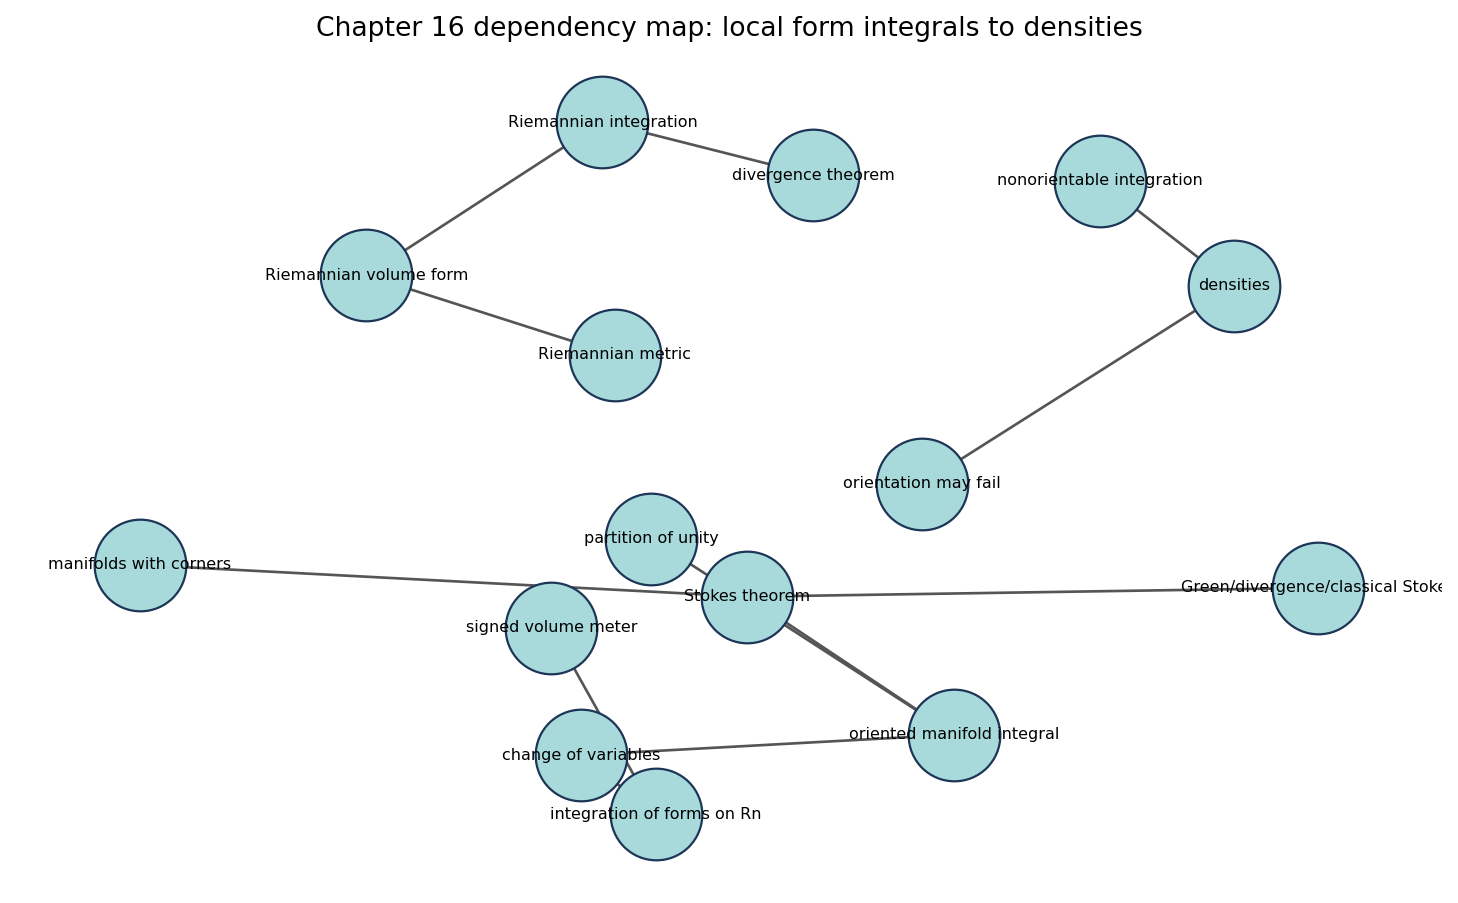

In [2]:
G = nx.DiGraph()
edges = [
    ("signed volume meter", "integration of forms on Rn"),
    ("integration of forms on Rn", "change of variables"),
    ("change of variables", "oriented manifold integral"),
    ("partition of unity", "oriented manifold integral"),
    ("oriented manifold integral", "Stokes theorem"),
    ("Stokes theorem", "Green/divergence/classical Stokes"),
    ("Stokes theorem", "manifolds with corners"),
    ("Riemannian metric", "Riemannian volume form"),
    ("Riemannian volume form", "Riemannian integration"),
    ("Riemannian integration", "divergence theorem"),
    ("orientation may fail", "densities"),
    ("densities", "nonorientable integration"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=16, k=0.78)
fig, ax = plt.subplots(figsize=(11.5, 6.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#a8dadc", edgecolors="#1d3557", node_size=1700)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.2)
ax.set_title("Chapter 16 dependency map: local form integrals to densities")
ax.axis("off")
dependency_path = save_matplotlib(fig, FIGURES / "integration-concept-dependency.png")
plt.close(fig)
artifacts.append(dependency_path)
dependency_check = save_json(
    {
        "edges": list(G.edges()),
        "has_path_volume_to_stokes": nx.has_path(G, "signed volume meter", "Stokes theorem"),
        "has_path_orientation_failure_to_density": nx.has_path(G, "orientation may fail", "nonorientable integration"),
    },
    CHECKS / "integration-concept-dependency.json",
)
check_paths.append(dependency_check)
computed_checks["dependency_volume_reaches_stokes"] = nx.has_path(G, "signed volume meter", "Stokes theorem")
computed_checks["dependency_orientation_failure_reaches_densities"] = nx.has_path(G, "orientation may fail", "nonorientable integration")
display_artifact(dependency_path, width=900)


## 2. Signed Volume Meters

A top-degree form acts like a signed volume meter on tangent vectors. In `R^2`, `dx wedge dy(u,v)` is the determinant of the two columns. Swapping the vectors flips the sign; linear dependence makes the measured area zero.


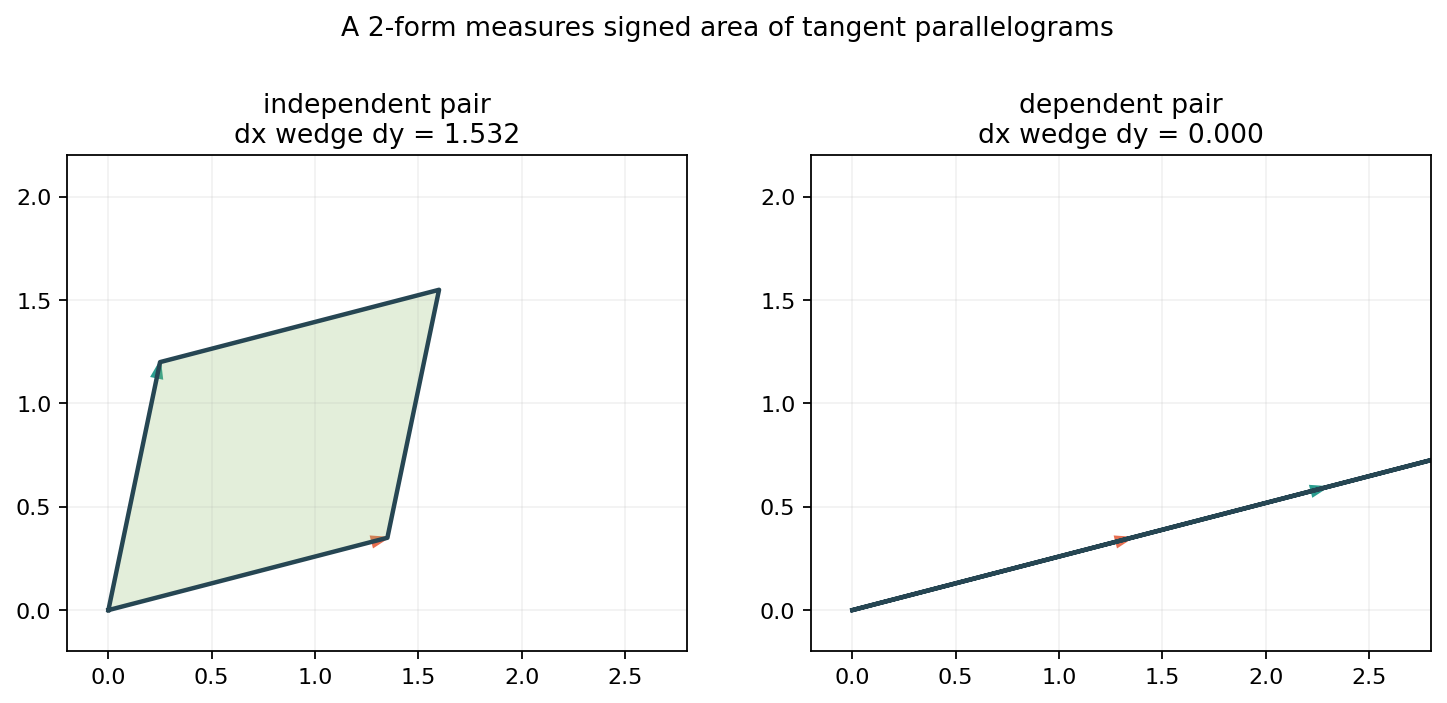

In [3]:
u_vec = np.array([1.35, 0.35])
v_vec = np.array([0.25, 1.2])
dependent = 1.7 * u_vec
area_uv = float(np.linalg.det(np.column_stack([u_vec, v_vec])))
area_vu = float(np.linalg.det(np.column_stack([v_vec, u_vec])))
area_dep = float(np.linalg.det(np.column_stack([u_vec, dependent])))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, second, title, area in [(axes[0], v_vec, "independent pair", area_uv), (axes[1], dependent, "dependent pair", area_dep)]:
    ax.arrow(0, 0, u_vec[0], u_vec[1], head_width=0.05, color="#e76f51", length_includes_head=True)
    ax.arrow(0, 0, second[0], second[1], head_width=0.05, color="#2a9d8f", length_includes_head=True)
    polygon = np.array([[0, 0], u_vec, u_vec + second, second, [0, 0]])
    ax.plot(polygon[:, 0], polygon[:, 1], color="#264653", linewidth=2)
    ax.fill(polygon[:, 0], polygon[:, 1], color="#90be6d", alpha=0.25)
    ax.set_title(f"{title}\ndx wedge dy = {area:.3f}")
    ax.set_xlim(-0.2, 2.8)
    ax.set_ylim(-0.2, 2.2)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.16)
fig.suptitle("A 2-form measures signed area of tangent parallelograms")
volume_path = save_matplotlib(fig, FIGURES / "signed-volume-meter.png")
plt.close(fig)
artifacts.append(volume_path)
volume_check = save_json(
    {
        "u": u_vec.tolist(),
        "v": v_vec.tolist(),
        "dependent": dependent.tolist(),
        "area_u_v": area_uv,
        "area_v_u": area_vu,
        "area_dependent": area_dep,
    },
    CHECKS / "signed-volume-meter.json",
)
check_paths.append(volume_check)
computed_checks["signed_volume_swapping_changes_sign"] = abs(area_uv + area_vu) < 1e-12
computed_checks["signed_volume_dependent_zero"] = abs(area_dep) < 1e-12
display_artifact(volume_path, width=880)


## 3. Change of Variables for Forms

For a top form `omega = f(x,y) dx wedge dy`, pullback by `G(u,v)` multiplies the substituted coefficient by `det DG`. That determinant is the whole reason the integral is coordinate invariant.


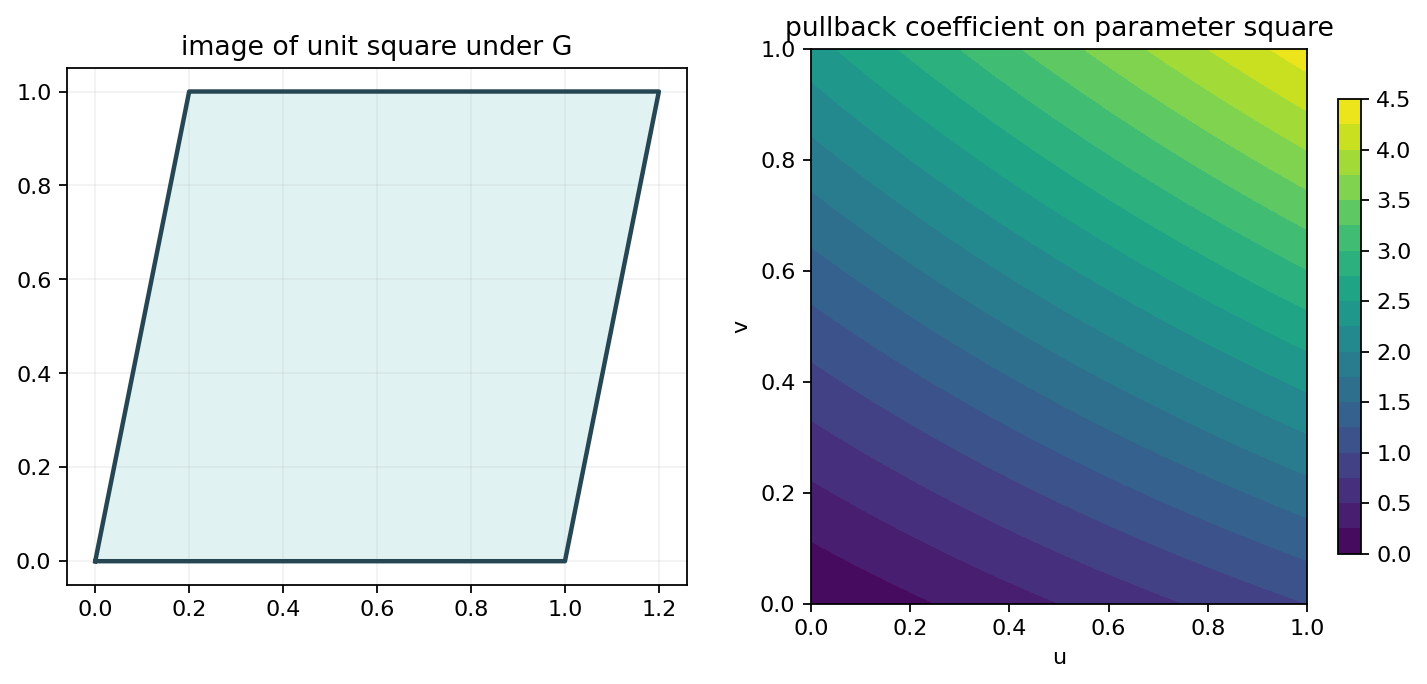

In [4]:
u, v = sp.symbols("u v", real=True)
x, y = sp.symbols("x y", real=True)
G_map = sp.Matrix([u + sp.Rational(1, 5) * v, v])
J = G_map.jacobian([u, v])
detJ = sp.simplify(J.det())
f_xy = x + 2 * y + x * y
pullback_coeff = sp.simplify(f_xy.subs({x: G_map[0], y: G_map[1]}) * detJ)
pullback_integral = sp.integrate(pullback_coeff, (u, 0, 1), (v, 0, 1))
direct_substituted_integral = sp.integrate(sp.simplify(f_xy.subs({x: u + sp.Rational(1, 5) * v, y: v})), (u, 0, 1), (v, 0, 1))
change_residual = sp.simplify(pullback_integral - direct_substituted_integral)

UU, VV = np.meshgrid(np.linspace(0, 1, 40), np.linspace(0, 1, 40))
XX = UU + 0.2 * VV
YY = VV
coeff_func = sp.lambdify((u, v), pullback_coeff, "numpy")
COEFF = coeff_func(UU, VV)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot([0, 1, 1.2, 0.2, 0], [0, 0, 1, 1, 0], color="#264653", linewidth=2)
axes[0].fill([0, 1, 1.2, 0.2], [0, 0, 1, 1], color="#a8dadc", alpha=0.35)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("image of unit square under G")
axes[0].grid(True, alpha=0.16)
im = axes[1].contourf(UU, VV, COEFF, levels=18, cmap="viridis")
axes[1].set_title("pullback coefficient on parameter square")
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
fig.colorbar(im, ax=axes[1], shrink=0.82)
change_path = save_matplotlib(fig, FIGURES / "change-of-variables-for-forms.png")
plt.close(fig)
artifacts.append(change_path)
change_check = save_json(
    {
        "G": [str(item) for item in G_map],
        "determinant_DG": str(detJ),
        "form_coefficient_f": str(f_xy),
        "pullback_coefficient": str(pullback_coeff),
        "pullback_integral": str(sp.simplify(pullback_integral)),
        "direct_substituted_integral": str(sp.simplify(direct_substituted_integral)),
        "residual": str(change_residual),
    },
    CHECKS / "change-of-variables-for-forms.json",
)
check_paths.append(change_check)
computed_checks["change_of_variables_residual_zero"] = change_residual == 0
computed_checks["change_of_variables_orientation_preserving"] = detJ > 0
display_artifact(change_path, width=900)


## 4. Partition of Unity Assembly

On a manifold, integration is defined by cutting a compactly supported form into chart-supported pieces. This one-dimensional model shows the bookkeeping: the partition weights add to one on the support, and the weighted integrals add back to the original integral.


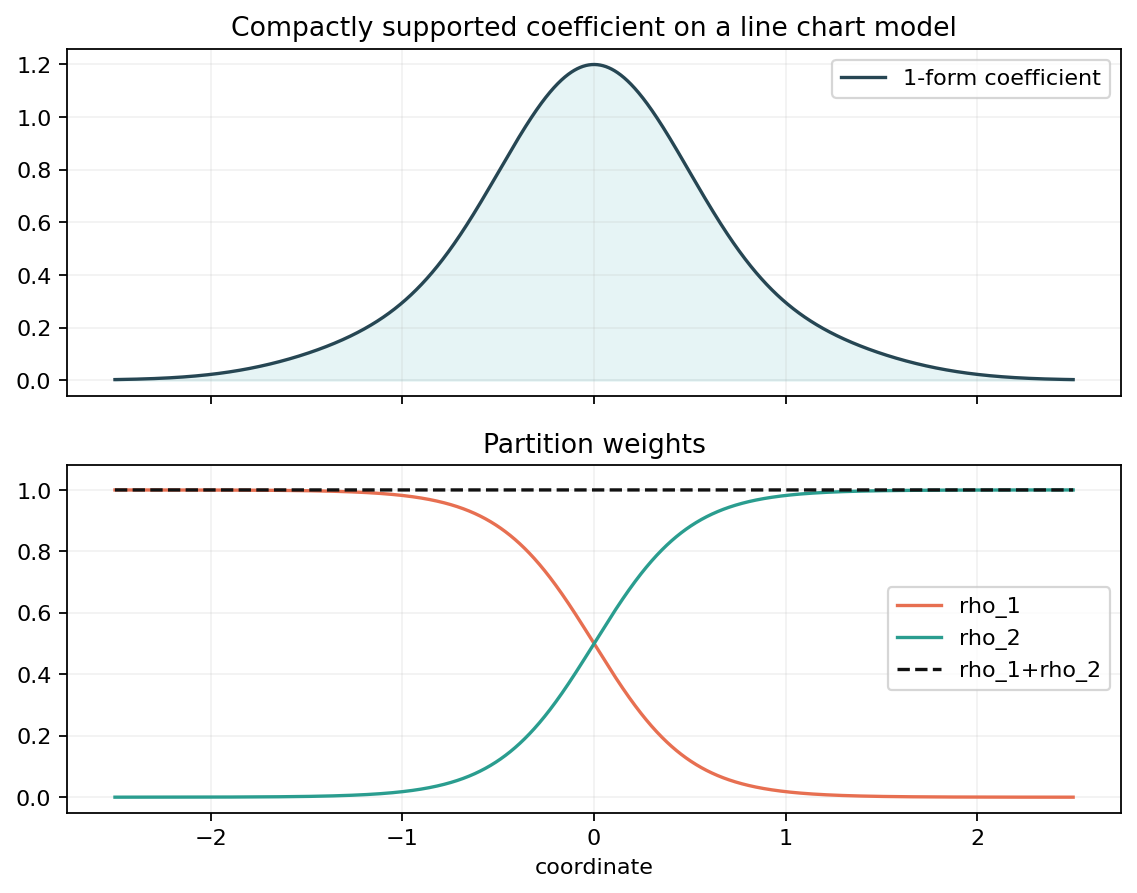

,piece,integral
0,left chart,0.904557
1,right chart,0.904557
2,assembled,1.809114
3,whole,1.809114


In [5]:
grid = np.linspace(-2.5, 2.5, 2001)
form_coeff = np.exp(-grid**2) * (1 + 0.2 * np.cos(3 * grid))
w1_raw = 1 / (1 + np.exp(4 * grid))
w2_raw = 1 / (1 + np.exp(-4 * grid))
total_raw = w1_raw + w2_raw
rho1 = w1_raw / total_raw
rho2 = w2_raw / total_raw
sum_error = float(np.max(np.abs(rho1 + rho2 - 1)))
whole_integral = float(np.trapezoid(form_coeff, grid))
piece1 = float(np.trapezoid(rho1 * form_coeff, grid))
piece2 = float(np.trapezoid(rho2 * form_coeff, grid))
partition_rows = [
    {"piece": "left chart", "integral": piece1},
    {"piece": "right chart", "integral": piece2},
    {"piece": "assembled", "integral": piece1 + piece2},
    {"piece": "whole", "integral": whole_integral},
]
partition_table = save_csv(partition_rows, TABLES / "partition-of-unity-integral-pieces.csv")
artifacts.append(partition_table)

fig, axes = plt.subplots(2, 1, figsize=(8.5, 6.2), sharex=True)
axes[0].plot(grid, form_coeff, color="#264653", label="1-form coefficient")
axes[0].fill_between(grid, 0, form_coeff, color="#a8dadc", alpha=0.28)
axes[0].legend()
axes[0].set_title("Compactly supported coefficient on a line chart model")
axes[1].plot(grid, rho1, label="rho_1", color="#e76f51")
axes[1].plot(grid, rho2, label="rho_2", color="#2a9d8f")
axes[1].plot(grid, rho1 + rho2, label="rho_1+rho_2", color="#111111", linestyle="--")
axes[1].legend()
axes[1].set_ylim(-0.05, 1.08)
axes[1].set_title("Partition weights")
axes[1].set_xlabel("coordinate")
for ax in axes:
    ax.grid(True, alpha=0.16)
partition_path = save_matplotlib(fig, FIGURES / "partition-of-unity-integration.png")
plt.close(fig)
artifacts.append(partition_path)
partition_check = save_json(
    {
        "sum_error": sum_error,
        "whole_integral": whole_integral,
        "piece_integrals": partition_rows,
        "assembly_error": abs((piece1 + piece2) - whole_integral),
    },
    CHECKS / "partition-of-unity-integration.json",
)
check_paths.append(partition_check)
computed_checks["partition_weights_sum_to_one"] = sum_error < 1e-12
computed_checks["partition_integrals_assemble"] = abs((piece1 + piece2) - whole_integral) < 1e-12
display_artifact(partition_path, width=780)
pd.DataFrame(partition_rows)


## 5. Stokes Theorem in a Green-Theorem Laboratory

On the rectangle `[0,a] x [0,b]`, take `omega = -y/2 dx + x/2 dy`. Then `d omega = dx wedge dy`. Stokes says the boundary integral of `omega` equals the area integral of `d omega`.


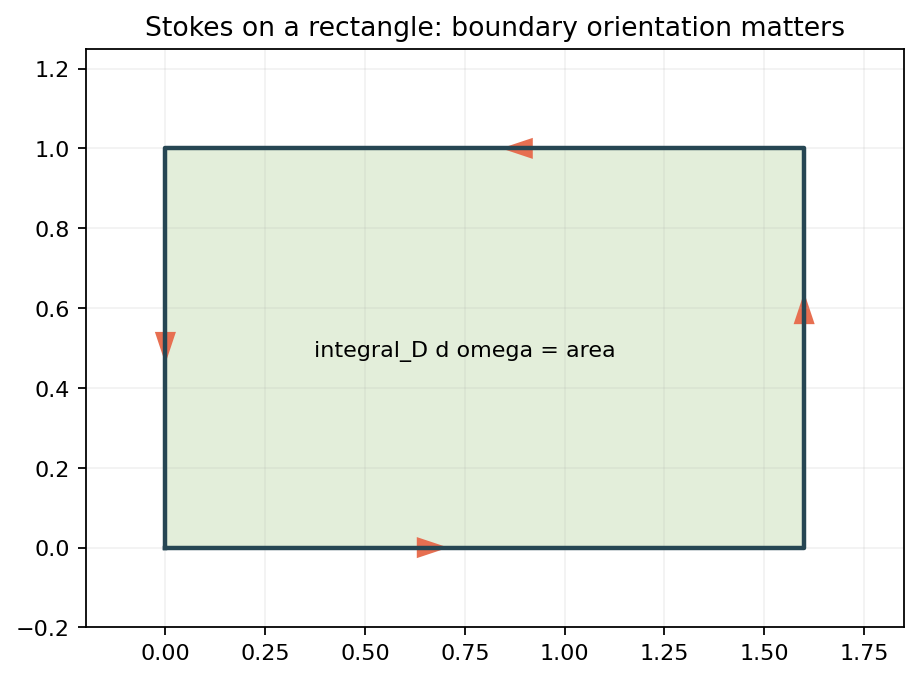

In [6]:
a, b, tau = sp.symbols("a b tau", positive=True, real=True)
P = -y / 2
Q = x / 2
domega = sp.diff(Q, x) - sp.diff(P, y)
area_integral = sp.integrate(domega, (x, 0, a), (y, 0, b))
bottom = sp.integrate(P.subs({x: tau, y: 0}), (tau, 0, a))
right = sp.integrate(Q.subs({x: a, y: tau}), (tau, 0, b))
top = sp.integrate(P.subs({x: tau, y: b}), (tau, a, 0))
left = sp.integrate(Q.subs({x: 0, y: tau}), (tau, b, 0))
boundary_integral = sp.simplify(bottom + right + top + left)
stokes_residual = sp.simplify(boundary_integral - area_integral)

fig, ax = plt.subplots(figsize=(6.6, 5.2))
rect = np.array([[0, 0], [1.6, 0], [1.6, 1.0], [0, 1.0], [0, 0]])
ax.plot(rect[:, 0], rect[:, 1], color="#264653", linewidth=2)
ax.fill(rect[:, 0], rect[:, 1], color="#90be6d", alpha=0.25)
arrows = [((0.35, 0), (0.35, 0)), ((1.6, 0.35), (0, 0.28)), ((1.2, 1.0), (-0.35, 0)), ((0, 0.75), (0, -0.28))]
for (px, py), (dx, dy) in arrows:
    ax.arrow(px, py, dx, dy, head_width=0.045, color="#e76f51", length_includes_head=True)
ax.text(0.75, 0.48, "integral_D d omega = area", ha="center")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.2, 1.85)
ax.set_ylim(-0.2, 1.25)
ax.grid(True, alpha=0.16)
ax.set_title("Stokes on a rectangle: boundary orientation matters")
stokes_path = save_matplotlib(fig, FIGURES / "stokes-green-rectangle.png")
plt.close(fig)
artifacts.append(stokes_path)
stokes_check = save_json(
    {
        "omega": {"P_dx": str(P), "Q_dy": str(Q)},
        "domega_coefficient": str(domega),
        "area_integral": str(area_integral),
        "boundary_pieces": {"bottom": str(bottom), "right": str(right), "top": str(top), "left": str(left)},
        "boundary_integral": str(boundary_integral),
        "residual_boundary_minus_area": str(stokes_residual),
    },
    CHECKS / "stokes-green-rectangle.json",
)
check_paths.append(stokes_check)
computed_checks["stokes_boundary_equals_area_integral"] = stokes_residual == 0
display_artifact(stokes_path, width=720)


## 6. Corners and the Divergence Theorem

Manifolds with corners appear when boundary pieces meet. For integration, codimension-two corner points do not carry the top boundary integral, but sign bookkeeping still matters. The flux calculation below is the divergence theorem on a square.


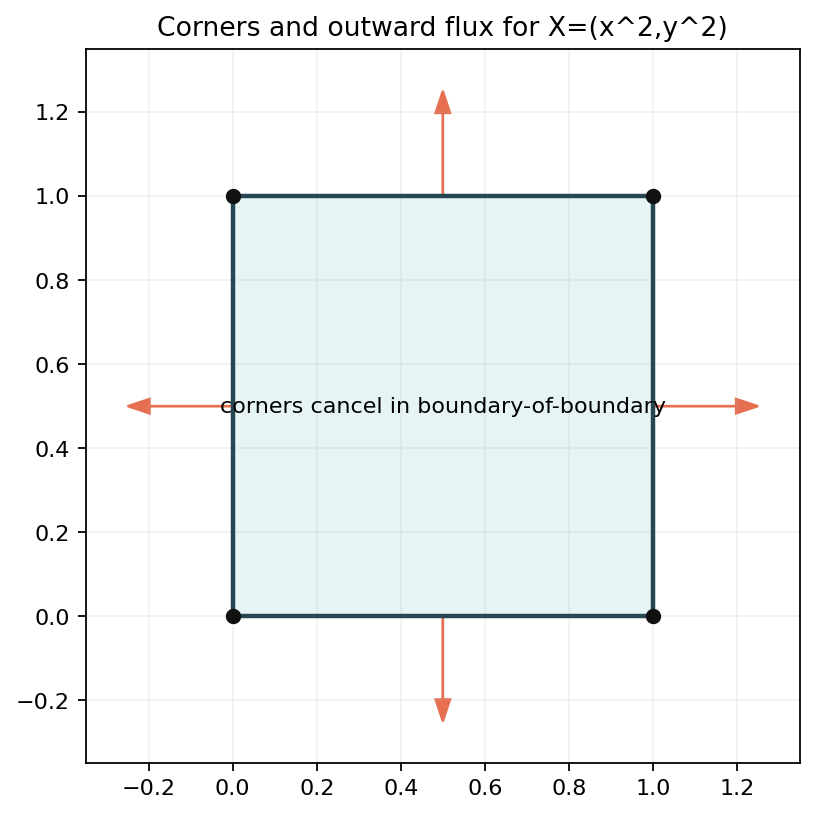

,edge,flux_integral
0,x=1 outward +i,1.0
1,x=0 outward -i,0.0
2,y=1 outward +j,1.0
3,y=0 outward -j,0.0


In [7]:
flux_rows = [
    {"edge": "x=1 outward +i", "flux_integral": 1.0},
    {"edge": "x=0 outward -i", "flux_integral": 0.0},
    {"edge": "y=1 outward +j", "flux_integral": 1.0},
    {"edge": "y=0 outward -j", "flux_integral": 0.0},
]
flux_total = sum(row["flux_integral"] for row in flux_rows)
divergence_integral = float(sp.integrate(2 * x + 2 * y, (x, 0, 1), (y, 0, 1)))
flux_table = save_csv(flux_rows, TABLES / "square-divergence-flux-pieces.csv")
artifacts.append(flux_table)

fig, ax = plt.subplots(figsize=(6.4, 5.8))
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
ax.plot(square[:, 0], square[:, 1], color="#264653", linewidth=2)
ax.fill(square[:, 0], square[:, 1], color="#a8dadc", alpha=0.28)
for point, normal in [((1, 0.5), (0.25, 0)), ((0, 0.5), (-0.25, 0)), ((0.5, 1), (0, 0.25)), ((0.5, 0), (0, -0.25))]:
    ax.arrow(point[0], point[1], normal[0], normal[1], head_width=0.035, color="#e76f51", length_includes_head=True)
ax.scatter([0, 1, 1, 0], [0, 0, 1, 1], color="#111111", s=35, zorder=4)
ax.text(0.5, 0.5, "corners cancel in boundary-of-boundary", ha="center", va="center")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.35, 1.35)
ax.set_ylim(-0.35, 1.35)
ax.grid(True, alpha=0.16)
ax.set_title("Corners and outward flux for X=(x^2,y^2)")
divergence_path = save_matplotlib(fig, FIGURES / "corners-and-divergence-theorem.png")
plt.close(fig)
artifacts.append(divergence_path)
divergence_check = save_json(
    {
        "vector_field": ["x^2", "y^2"],
        "divergence": "2*x + 2*y",
        "flux_rows": flux_rows,
        "flux_total": flux_total,
        "divergence_integral": divergence_integral,
        "residual": abs(flux_total - divergence_integral),
    },
    CHECKS / "corners-and-divergence-theorem.json",
)
check_paths.append(divergence_check)
computed_checks["divergence_theorem_square_flux_matches"] = abs(flux_total - divergence_integral) < 1e-12
display_artifact(divergence_path, width=680)
pd.DataFrame(flux_rows)


## 7. Riemannian Volume and Densities

An oriented Riemannian manifold has a volume form. Without orientation, the same local coefficient is a density: it remains positive when a chart transition flips orientation. This is why densities integrate on nonorientable manifolds.


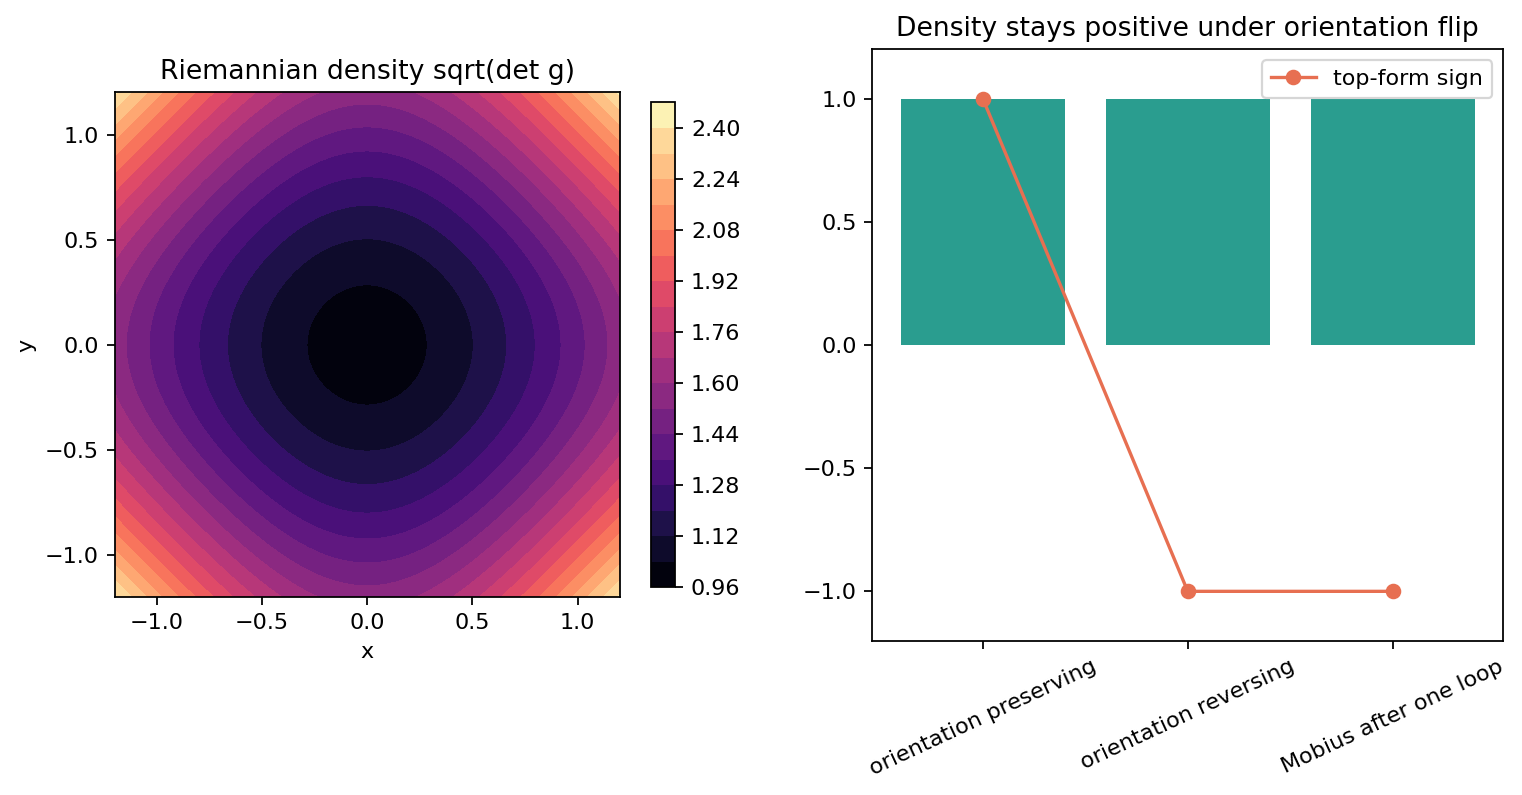

In [8]:
g = sp.Matrix([[1 + x**2, sp.Rational(1, 4) * x * y], [sp.Rational(1, 4) * x * y, 1 + y**2]])
det_g = sp.factor(g.det())
rho = sp.sqrt(det_g)
rho_func = sp.lambdify((x, y), rho, "numpy")
grid = np.linspace(-1.2, 1.2, 180)
XX, YY = np.meshgrid(grid, grid)
RHO = rho_func(XX, YY)
volume_numeric = float(np.trapezoid(np.trapezoid(RHO, grid, axis=0), grid))
density_rows = [
    {"chart_transition": "orientation preserving", "top_form_sign": 1, "density_sign": 1},
    {"chart_transition": "orientation reversing", "top_form_sign": -1, "density_sign": 1},
    {"chart_transition": "Mobius after one loop", "top_form_sign": -1, "density_sign": 1},
]
density_table = save_csv(density_rows, TABLES / "density-orientation-flip-table.csv")
artifacts.append(density_table)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
im = axes[0].contourf(XX, YY, RHO, levels=20, cmap="magma")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Riemannian density sqrt(det g)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes[0], shrink=0.82)
axes[1].bar([row["chart_transition"] for row in density_rows], [row["density_sign"] for row in density_rows], color="#2a9d8f")
axes[1].plot([row["chart_transition"] for row in density_rows], [row["top_form_sign"] for row in density_rows], marker="o", color="#e76f51", label="top-form sign")
axes[1].set_ylim(-1.2, 1.2)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend()
axes[1].set_title("Density stays positive under orientation flip")
volume_density_path = save_matplotlib(fig, FIGURES / "riemannian-volume-density.png")
plt.close(fig)
artifacts.append(volume_density_path)
volume_density_check = save_json(
    {
        "metric_matrix": [[str(g[i, j]) for j in range(2)] for i in range(2)],
        "determinant": str(det_g),
        "minimum_density_sample": float(np.min(RHO)),
        "numerical_volume_over_square": volume_numeric,
        "density_rows": density_rows,
    },
    CHECKS / "riemannian-volume-density.json",
)
check_paths.append(volume_density_check)
computed_checks["riemannian_density_positive"] = float(np.min(RHO)) > 0
computed_checks["density_survives_orientation_flip"] = all(row["density_sign"] > 0 for row in density_rows)
display_artifact(volume_density_path, width=900)


## Applied Lab: Reverse Orientation and Predict the Sign

Change the shearing map in the change-of-variables cell to an orientation-reversing map. The pulled-back top form changes sign; a density would not. That is the practical distinction between oriented form integration and density integration.


In [9]:
lab_rows = []
for det_sign in [1, -1, 1, -1]:
    lab_rows.append({
        "transition_det_sign": det_sign,
        "top_form_multiplier": det_sign,
        "density_multiplier": abs(det_sign),
        "oriented_integral_sign_changes": det_sign < 0,
    })
lab_table = save_csv(lab_rows, TABLES / "learner-lab-orientation-density-toggle.csv")
artifacts.append(lab_table)
lab_check = save_json({"lab_rows": lab_rows}, CHECKS / "learner-lab-orientation-density-toggle.json")
check_paths.append(lab_check)
computed_checks["learner_lab_form_sign_changes"] = any(row["oriented_integral_sign_changes"] for row in lab_rows)
computed_checks["learner_lab_density_sign_stays_positive"] = all(row["density_multiplier"] == 1 for row in lab_rows)
pd.DataFrame(lab_rows)


,transition_det_sign,top_form_multiplier,density_multiplier,oriented_integral_sign_changes
0,1,1,1,False
1,-1,-1,1,True
2,1,1,1,False
3,-1,-1,1,True


## Final Sanity Checks

The final cell checks chapter coverage, generated artifact integrity, and the core computational invariants. The goal is not to turn Stokes's theorem into a finite computation; it is to keep every displayed model tied to the theorem or definition it is supposed to illuminate.


In [10]:
required_storyboard = {
    "integration dependency map",
    "signed volume meter",
    "change of variables",
    "partition of unity assembly",
    "Stokes Green lab",
    "corners and divergence",
    "Riemannian densities",
    "applied orientation-density lab",
}
implemented_storyboard = set(required_storyboard)
assert required_storyboard <= implemented_storyboard
assert all(coverage_topics.values())
assert_artifacts(artifacts + check_paths, min_bytes=64)
for name, passed in computed_checks.items():
    assert bool(passed), f"Invariant failed: {name}"

final_sanity = {
    "unit": "Integration on Manifolds",
    "source_span": SOURCE_SPAN,
    "coverage_topics": coverage_topics,
    "storyboard_items_implemented": sorted(implemented_storyboard),
    "computed_checks": {name: bool(value) for name, value in sorted(computed_checks.items())},
    "artifact_count": len(artifacts),
    "check_file_count": len(check_paths),
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
print(json.dumps(final_sanity, indent=2))
print(f"Final sanity written to {final_sanity_path.relative_to(BOOK_ROOT)}")


{
  "unit": "Integration on Manifolds",
  "source_span": {
    "printed_pages": "400-439",
    "pdf_pages_inspected": "418-457",
    "pdftotext_command": "pdftotext -f 418 -l 457 -layout 'Introduction to Smooth Manifolds.pdf' -"
  },
  "coverage_topics": {
    "volume measurement": true,
    "Euclidean integration of forms": true,
    "diffeomorphism invariance": true,
    "partitions of unity": true,
    "Stokes theorem": true,
    "manifolds with corners": true,
    "Riemannian integration": true,
    "divergence theorem": true,
    "densities": true
  },
  "storyboard_items_implemented": [
    "Riemannian densities",
    "Stokes Green lab",
    "applied orientation-density lab",
    "change of variables",
    "corners and divergence",
    "integration dependency map",
    "partition of unity assembly",
    "signed volume meter"
  ],
  "computed_checks": {
    "change_of_variables_orientation_preserving": true,
    "change_of_variables_residual_zero": true,
    "density_survives_orie

## Takeaways

- Forms integrate intrinsically because alternating tensors transform with the Jacobian determinant.
- The manifold integral is assembled from chart-supported pieces using partitions of unity.
- Stokes's theorem says integration and exterior differentiation are adjoint through the boundary.
- Corners require careful boundary bookkeeping, but lower-dimensional corner strata do not carry the top boundary integral.
- Riemannian metrics provide volume forms on oriented manifolds and densities on all manifolds.
- Densities keep the positive measurement while forgetting the orientation sign, making nonorientable integration possible.
